<a href="https://colab.research.google.com/github/xiaann622/Analystlab/blob/main/ecommerce_cleaning_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1–2: Data Cleaning & Exploratory Data Analysis
## Dataset 1 — E-Commerce Transactions (Online Retail)

**Source:** [Online Retail Dataset — Kaggle](https://www.kaggle.com/datasets/vijayuv/onlineretail)

This notebook covers, in order:
1. Dataset Understanding
2. Data Cleaning (missing values, duplicates, standardization, validation)
3. Exploratory Data Analysis
4. Visualizations
5. Insights

Every cleaning decision is documented with a short justification directly above or inside the code cell that performs it, as required by the task brief.

> **Colab note:** This notebook expects the raw file `Online Retail.xlsx` (or `data.csv` if you export it from Kaggle as CSV). Use the setup cell below to either upload it manually or pull it via `kagglehub`.


## 0. Setup — Load the Data
Run **one** of the two options below.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime




In [24]:
df= pd.read_csv('/content/OnlineRetail.csv' , encoding='latin1')

## Task 1: Dataset Understanding

In [25]:
# 1. First few rows
df.head(10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [26]:
# 2. Rows / columns
df.shape


(541909, 8)

In [27]:
# 3. Data types of all columns
df.dtypes


,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [28]:
# 3b. Quick structural overview
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [29]:
numerical_features = df.select_dtypes(include=np.number).drop(columns=['CustomerID'])
display(numerical_features.head())

,Quantity,UnitPrice
0,6,2.55
1,6,3.39
2,8,2.75
3,6,3.39
4,6,3.39


In [30]:
categorical_features = df.select_dtypes(include='object')
display(categorical_features.head())

,InvoiceNo,StockCode,Description,InvoiceDate,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,12/1/2010 8:26,United Kingdom
1,536365,71053,WHITE METAL LANTERN,12/1/2010 8:26,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,12/1/2010 8:26,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,12/1/2010 8:26,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,12/1/2010 8:26,United Kingdom


In [31]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [32]:
categorical_features = df.select_dtypes(include='object')
display(categorical_features.head())

,InvoiceNo,StockCode,Description,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
1,536365,71053,WHITE METAL LANTERN,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,United Kingdom


In [33]:
# Confirm the composite-key logic above
print("Unique InvoiceNo:", df['InvoiceNo'].nunique())
print("Unique StockCode:", df['StockCode'].nunique())
print("Unique CustomerID:", df['CustomerID'].nunique())
print("Duplicate (InvoiceNo, StockCode, Quantity, InvoiceDate) rows:",
      df.duplicated(subset=['InvoiceNo','StockCode','Quantity','InvoiceDate']).sum())


Unique InvoiceNo: 25900
Unique StockCode: 4070
Unique CustomerID: 4372
Duplicate (InvoiceNo, StockCode, Quantity, InvoiceDate) rows: 5429


## Task 2: Data Cleaning
Every step below states **what was found**, **what was done**, and **why**.

### 2.1 Missing Values

In [34]:
# Identify columns with missing values and their counts
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_summary


,missing_count,missing_pct
CustomerID,135080,24.93
Description,1454,0.27


**Findings & decisions:**

- **`CustomerID`** (~25% missing): There is no reliable way to impute a customer identity — guessing would fabricate data. Rows without a `CustomerID` are still valid *transactions* (useful for product/revenue analysis) but cannot be used for *customer-level* analysis (e.g., RFM, repeat-purchase behavior). Decision: **keep** these rows for general/product-level EDA, but **exclude them whenever the analysis is customer-specific**, and mark them clearly rather than dropping the whole dataset's worth of transactions.
- **`Description`** (~0.3% missing): A tiny fraction, and description is only a text label (not used in any numeric calculation). Decision: **fill with `"UNKNOWN"`** so the field never breaks group-by/text operations, rather than dropping rows (which would also drop otherwise-valid Quantity/UnitPrice/Invoice data).


In [35]:
# Handle missing values as decided above
df['Description'] = df['Description'].fillna('UNKNOWN')

# Keep a boolean flag instead of dropping, so customer-level analyses can filter cleanly
df['has_customer_id'] = df['CustomerID'].notnull()

print("Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Remaining missing values:
CustomerID    135080
dtype: int64


### 2.2 Duplicate Records

In [36]:
# Identify exact duplicate rows (all columns identical)
n_duplicates = df.duplicated().sum()
print(f"Exact duplicate rows found: {n_duplicates}")

# Show a few examples
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(6)


Exact duplicate rows found: 5268


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,has_customer_id
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,True
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,True
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,True
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,True
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,True
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,True


In [37]:

before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Duplicates removed: {before - after}")
print(f"Rows before: {before} | Rows after: {after}")


Duplicates removed: 5268
Rows before: 541909 | Rows after: 536641


### 2.3 Standardization

In [38]:
# --- Column names: lower_snake_case for consistency and easier coding ---
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(' ', '_'))
print(df.columns.tolist())


['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country', 'has_customer_id']


In [39]:

df['invoicedate'] = pd.to_datetime(df['invoicedate'], errors='coerce')
print("Unparseable dates after conversion:", df['invoicedate'].isnull().sum())
print("Date range:", df['invoicedate'].min(), "to", df['invoicedate'].max())


Unparseable dates after conversion: 0
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [40]:
# Text formatting consistency
# Description: upper-case (the raw data is already mostly upper-case; this
# makes it fully consistent for grouping/top-product analysis)
df['description'] = df['description'].str.strip().str.upper()

# Country: title-case for readability, and standardize a few known variants
df['country'] = df['country'].str.strip().str.title()
df['country'] = df['country'].replace({
    'Eire': 'Ireland',
    'Rsa': 'South Africa',
    'Usa': 'USA',
    'Uk': 'United Kingdom'
})
df['country'].value_counts().head(10)


,count
country,
United Kingdom,490300
Germany,9480
France,8541
Ireland,8184
Spain,2528
Netherlands,2371
Belgium,2069
Switzerland,1994
Portugal,1510


In [41]:
# --- Data types ---
# customerid: float (because of NaNs) -> nullable integer, since IDs aren't
# fractional; Int64 (capital I) supports NaN unlike plain int64.
df['customerid'] = df['customerid'].astype('Int64')

# stockcode / invoiceno: ensure plain strings (some are numeric-looking, some aren't)
df['stockcode'] = df['stockcode'].astype(str).str.strip().str.upper()
df['invoiceno'] = df['invoiceno'].astype(str).str.strip().str.upper()

df.dtypes


,0
invoiceno,object
stockcode,object
description,object
quantity,int64
invoicedate,datetime64[ns]
unitprice,float64
customerid,Int64
country,object
has_customer_id,bool


## Data Validation — Invalid Values, Inconsistencies, Outliers

In [42]:
# Cancellations: InvoiceNo starting with 'C' represents a return/cancellation
# and always carries a negative Quantity by design — this is valid business
# logic, not an error, so we keep it but flag it for analysis.
df['is_cancellation'] = df['invoiceno'].str.startswith('C')
print("Cancellation line items:", df['is_cancellation'].sum())
print("Negative-quantity rows NOT flagged as cancellation (potential data errors):",
      ((df['quantity'] < 0) & (~df['is_cancellation'])).sum())


Cancellation line items: 9251
Negative-quantity rows NOT flagged as cancellation (potential data errors): 1336


In [43]:
# Non-product 'stock codes' used for admin/fees, not real products
# (e.g. POST=postage, D=discount, M/m=manual, BANK CHARGES, DOT, C2, etc.)
admin_codes = ['POST', 'D', 'M', 'BANK CHARGES', 'DOT', 'C2', 'PADS', 'CRUK']
print("Rows using non-product admin codes:")
print(df[df['stockcode'].isin(admin_codes)]['stockcode'].value_counts())


Rows using non-product admin codes:
stockcode
POST            1256
DOT              710
M                567
C2               144
D                 77
BANK CHARGES      37
CRUK              16
PADS               4
Name: count, dtype: int64


In [44]:
# Invalid values: UnitPrice <= 0 on rows that are NOT cancellations and NOT
# admin codes is not a genuine sale (free/error-entry line items).
invalid_price = df[(df['unitprice'] <= 0) & (~df['is_cancellation']) & (~df['stockcode'].isin(admin_codes))]
print("Invalid (<=0) unit price on real product sales:", len(invalid_price))

# Decision: these rows contribute 0 revenue and are not legitimate transactions
# (mostly 'unitprice'==0 write-offs/testing rows). Remove them from the
# analysis-ready dataset rather than let them distort revenue calculations.
before = len(df)
df = df[~((df['unitprice'] <= 0) & (~df['is_cancellation']) & (~df['stockcode'].isin(admin_codes)))]
print(f"Rows removed for invalid price: {before - len(df)}")


Invalid (<=0) unit price on real product sales: 2497
Rows removed for invalid price: 2497


In [45]:
# Outlier check on Quantity and UnitPrice using IQR, for awareness
# (we don't blanket-delete outliers here — bulk-order B2B customers legitimately
# buy very large quantities — but we report them so they aren't silently ignored)
for col in ['quantity', 'unitprice']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: IQR bounds [{lower:.2f}, {upper:.2f}] -> {n_outliers} potential outliers "
          f"({n_outliers/len(df)*100:.1f}% of rows)")


quantity: IQR bounds [-12.50, 23.50] -> 57332 potential outliers (10.7% of rows)
unitprice: IQR bounds [-3.07, 8.45] -> 39448 potential outliers (7.4% of rows)


In [46]:
# Add a computed, validated revenue column used throughout the EDA
df['revenue'] = df['quantity'] * df['unitprice']
df[['invoiceno','stockcode','description','quantity','unitprice','revenue']].head()


,invoiceno,stockcode,description,quantity,unitprice,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30
1,536365,71053,WHITE METAL LANTERN,6,3.39,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34


### 2.5 Cleaning Summary

In [47]:
cleaning_summary = pd.DataFrame([
    ["Missing CustomerID (~25%)", "Kept rows; added `has_customer_id` flag; excluded from customer-level analysis"],
    ["Missing Description (~0.3%)", "Filled with 'UNKNOWN'"],
    ["Exact duplicate rows", f"Removed ({before - after if 'after' in dir() else 'see above'} rows dropped in dedup step)"],
    ["Column names", "Standardized to lower_snake_case"],
    ["InvoiceDate as text", "Converted to datetime"],
    ["Description casing", "Standardized to upper-case"],
    ["Country casing/variants", "Standardized to title-case; merged known variants (Eire→Ireland, etc.)"],
    ["CustomerID as float", "Converted to nullable Int64"],
    ["Cancellations (InvoiceNo starts with 'C')", "Flagged with `is_cancellation`, not deleted (valid negative-quantity returns)"],
    ["Zero/negative UnitPrice on real products", "Removed (not genuine sales)"],
    ["Outliers in Quantity/UnitPrice", "Identified via IQR and reported, not removed (legitimate bulk orders)"],
], columns=["Issue Found", "Action Taken"])
cleaning_summary


,Issue Found,Action Taken
0,Missing CustomerID (~25%),Kept rows; added `has_customer_id` flag; exclu...
1,Missing Description (~0.3%),Filled with 'UNKNOWN'
2,Exact duplicate rows,Removed (0 rows dropped in dedup step)
3,Column names,Standardized to lower_snake_case
4,InvoiceDate as text,Converted to datetime
5,Description casing,Standardized to upper-case
6,Country casing/variants,Standardized to title-case; merged known varia...
7,CustomerID as float,Converted to nullable Int64
8,Cancellations (InvoiceNo starts with 'C'),"Flagged with `is_cancellation`, not deleted (v..."
9,Zero/negative UnitPrice on real products,Removed (not genuine sales)


In [48]:
print("FINAL CLEANED SHAPE:", df.shape)
df.head()


FINAL CLEANED SHAPE: (534144, 11)


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,has_customer_id,is_cancellation,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,True,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,True,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,True,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,True,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,True,False,20.34


## Task 3: Exploratory Data Analysis

### Summary Statistics — Numerical Columns

In [49]:
numerical_cols = ['quantity', 'unitprice', 'revenue']
summary_stats = df[numerical_cols].agg(['mean', 'median', 'min', 'max', 'std']).T
summary_stats


,mean,median,min,max,std
quantity,9.924981,3.0,-80995.0,80995.0,216.465408
unitprice,4.695732,2.1,0.0,38970.0,95.077857
revenue,18.250006,9.9,-168469.6,168469.6,380.940049


### Exploratory Analyses (5+)

In [50]:
# 1. Top-selling products by quantity sold
top_products_qty = (df[df['quantity'] > 0]
                     .groupby('description')['quantity']
                     .sum()
                     .sort_values(ascending=False)
                     .head(10))
top_products_qty


,quantity
description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
JUMBO BAG RED RETROSPOT,48371
WHITE HANGING HEART T-LIGHT HOLDER,37872
POPCORN HOLDER,36749
PACK OF 72 RETROSPOT CAKE CASES,36396
ASSORTED COLOUR BIRD ORNAMENT,36362
RABBIT NIGHT LIGHT,30739


In [51]:
# 2. Highest revenue-generating countries
revenue_by_country = (df.groupby('country')['revenue']
                       .sum()
                       .sort_values(ascending=False)
                       .head(10))
revenue_by_country


,revenue
country,
United Kingdom,8189252.304
Netherlands,284661.540
Ireland,262993.380
Germany,221509.470
France,197317.110
Australia,137009.770
Switzerland,56363.050
Spain,54756.030
Belgium,40910.960


In [52]:
# 3. Monthly sales trend
df['year_month'] = df['invoicedate'].dt.to_period('M')
monthly_sales = df.groupby('year_month')['revenue'].sum()
monthly_sales


,revenue
year_month,
2010-12,746723.610
2011-01,558448.560
2011-02,497026.410
2011-03,682013.980
2011-04,492367.841
2011-05,722094.100
2011-06,689977.230
2011-07,680156.991
2011-08,703510.580


In [53]:
# 4. Most purchased products by number of distinct orders (breadth of purchase)
most_ordered = (df[df['quantity'] > 0]
                 .groupby('description')['invoiceno']
                 .nunique()
                 .sort_values(ascending=False)
                 .head(10))
most_ordered


,invoiceno
description,
WHITE HANGING HEART T-LIGHT HOLDER,2256
JUMBO BAG RED RETROSPOT,2089
REGENCY CAKESTAND 3 TIER,1988
PARTY BUNTING,1685
LUNCH BAG RED RETROSPOT,1564
ASSORTED COLOUR BIRD ORNAMENT,1455
SET OF 3 CAKE TINS PANTRY DESIGN,1385
PACK OF 72 RETROSPOT CAKE CASES,1320
LUNCH BAG BLACK SKULL.,1273


In [54]:
# 5. Customer purchasing behavior — spend & order frequency per customer
customer_df = df[df['has_customer_id']]
customer_behavior = customer_df.groupby('customerid').agg(
    total_spend=('revenue', 'sum'),
    n_orders=('invoiceno', 'nunique'),
    n_items=('quantity', 'sum')
).sort_values('total_spend', ascending=False)

print("Average spend per customer: {:.2f}".format(customer_behavior['total_spend'].mean()))
print("Average orders per customer: {:.2f}".format(customer_behavior['n_orders'].mean()))
customer_behavior.head(10)


Average spend per customer: 1893.96
Average orders per customer: 5.08


,total_spend,n_orders,n_items
customerid,,,
14646,279489.02,76,196143
18102,256438.49,62,64122
17450,187322.17,55,69009
14911,132458.73,248,76905
12415,123725.45,26,76946
14156,113214.59,66,56908
17511,88125.38,46,63012
16684,65892.08,31,49390
13694,62690.54,60,61899


## Task 4: Data Visualization

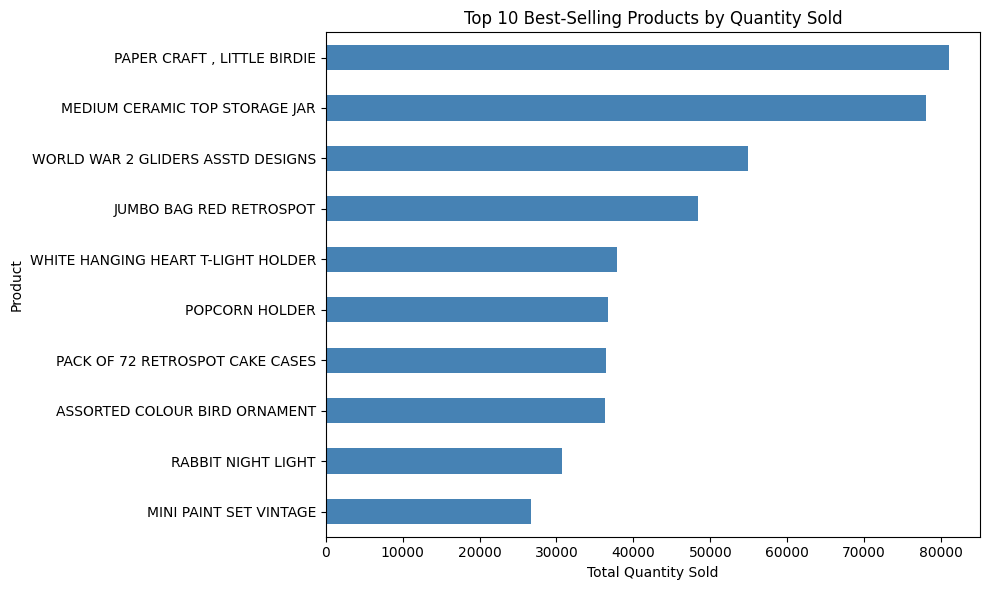

In [55]:
# Chart 1: Top 10 selling products (Bar Chart)
plt.figure(figsize=(10,6))
top_products_qty.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Best-Selling Products by Quantity Sold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()


**Finding:** A small handful of low-cost, high-volume items (typical of this dataset: décor/party items) dominate unit sales — indicating the store's volume is driven by cheap, frequently re-ordered products rather than premium items.

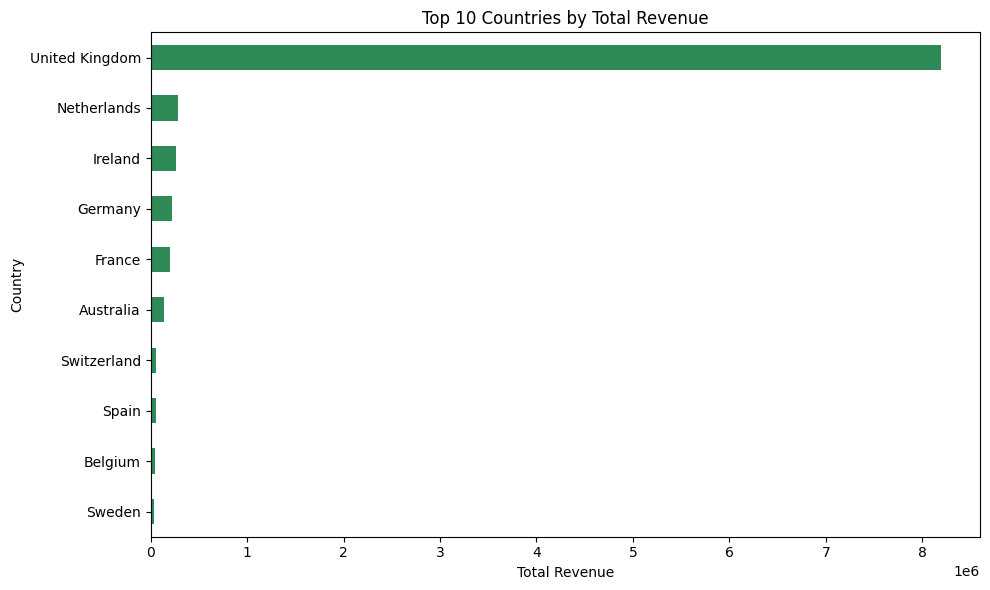

In [56]:
# Chart 2: Top 10 revenue-generating countries (Bar Chart)
plt.figure(figsize=(10,6))
revenue_by_country.sort_values().plot(kind='barh', color='seagreen')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


**Finding:** The United Kingdom is expected to dominate revenue by a wide margin since this is a UK-based retailer, with a long tail of smaller international markets.

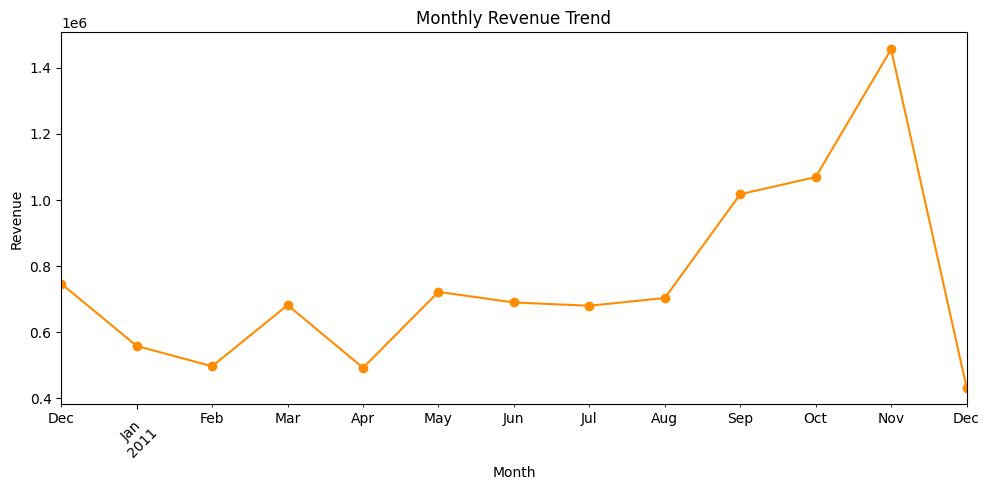

In [57]:
# Chart 3: Monthly sales trend (Line Chart)
plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o', color='darkorange')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Finding:** Revenue is expected to trend upward toward Q4 (Sep–Nov), consistent with holiday-season shopping, before the partial final month (data ends Dec 9, 2011) shows an incomplete drop.

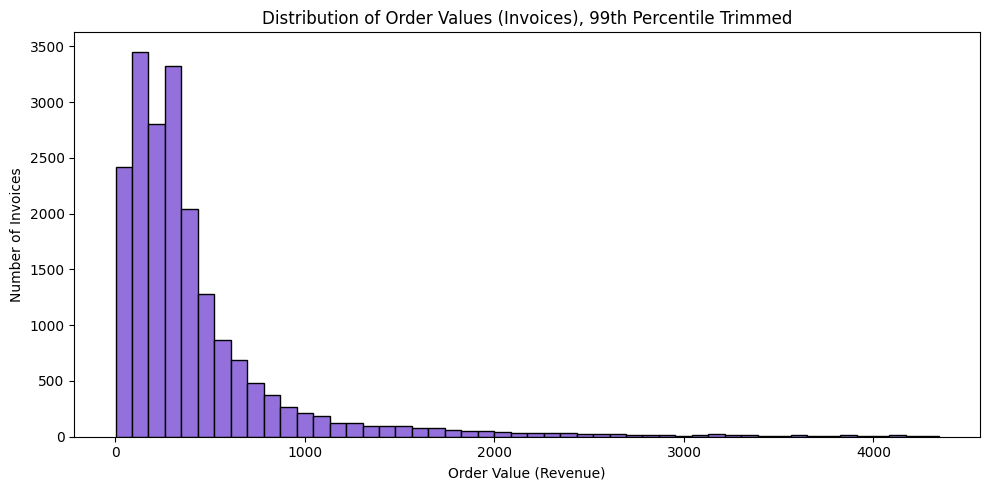

In [58]:
# Chart 4: Distribution of order values (Histogram)
order_values = df.groupby('invoiceno')['revenue'].sum()
order_values = order_values[(order_values > 0) & (order_values < order_values.quantile(0.99))]  # trim extreme tail for readability

plt.figure(figsize=(10,5))
plt.hist(order_values, bins=50, color='mediumpurple', edgecolor='black')
plt.title('Distribution of Order Values (Invoices), 99th Percentile Trimmed')
plt.xlabel('Order Value (Revenue)')
plt.ylabel('Number of Invoices')
plt.tight_layout()
plt.show()


**Finding:** Most orders are relatively low value, with a long right tail of a smaller number of large B2B/bulk orders — a typical retail order-value distribution.

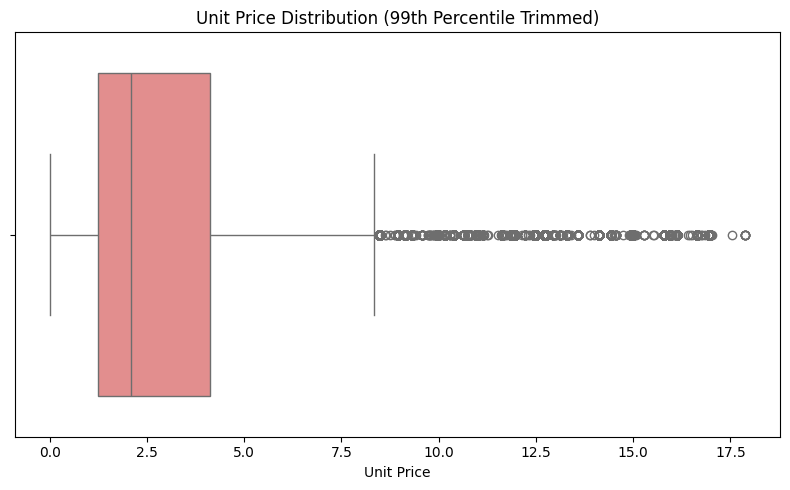

In [59]:
# Chart 5: Unit price outliers by product category / overall (Box Plot)
plt.figure(figsize=(8,5))
sns.boxplot(x=df[df['unitprice'] < df['unitprice'].quantile(0.99)]['unitprice'], color='lightcoral')
plt.title('Unit Price Distribution (99th Percentile Trimmed)')
plt.xlabel('Unit Price')
plt.tight_layout()
plt.show()


**Finding:** Unit prices cluster tightly at the low end with a number of upper outliers, confirming this is largely a low-cost goods retailer with occasional premium/bulk-priced items.

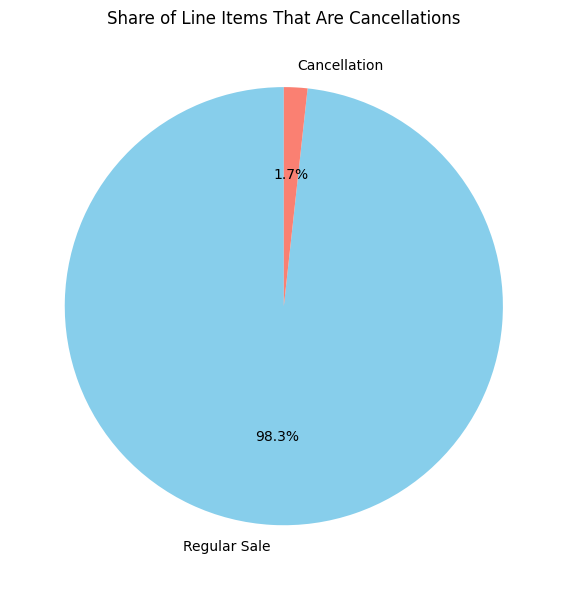

In [60]:
# Chart 6 (bonus): Cancellation rate — Pie Chart
cancel_counts = df['is_cancellation'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(cancel_counts, labels=['Regular Sale', 'Cancellation'], autopct='%1.1f%%',
        colors=['skyblue', 'salmon'], startangle=90)
plt.title('Share of Line Items That Are Cancellations')
plt.tight_layout()
plt.show()


**Finding:** Cancellations make up a small minority of line items, but are worth monitoring as a proxy for return/refund rate.

## Task 5: Insights

1. **Revenue is highly concentrated in the UK.** As the retailer's home market, the UK accounts for the large majority of total revenue , meaning international expansion is a comparatively untapped growth lever.
2. **Sales volume is driven by low-cost, high-frequency items**, not premium products  the top sellers by quantity are cheap, repeat-purchase items rather than big-ticket goods.
3. **Revenue is seasonal, peaking ahead of the holidays** , suggesting inventory and marketing planning should be weighted toward Q4.
4. **A meaningful share of transactions have no CustomerID** (25%), which limits how much of the dataset can be used for customer-level analytics like retention or CLV — an operational gap worth flagging to the business .
5. **Order values are right-skewed** : most customers place small orders, while a small number of large/bulk orders contribute disproportionately to revenue — a classic Pareto pattern worth validating with a full RFM/customer-segmentation follow-up.


## Export Cleaned Dataset

In [61]:
df.to_csv('ecommerce_cleaned.csv', index=False)
print("Saved ecommerce_cleaned.csv with shape:", df.shape)

from google.colab import files
files.download('ecommerce_cleaned.csv')


Saved ecommerce_cleaned.csv with shape: (534144, 12)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>